Libraries

In [107]:
import numpy as np
import scipy.linalg as la
from scipy.linalg import solve
import matplotlib.pyplot as plt
import pandas as pd
import os

Function Evaluation Code

In [106]:
def polynomial(x, r=6, d=3):
    return pow(x - r, d)

def polynomial_prime(x, r=6, d=3):
    return d * pow(x - r, d - 1)

Methods

In [ ]:
def regula_falsi(a, b, function, x_true, TOL_error, TOL_residual, MAX_ITER):
    errors = np.zeros(MAX_ITER + 1)
    residuals = np.zeros(MAX_ITER + 1)
    iterations = 0
    x = a 

    if function(a) * function(b) > 0:
        print("No root guaranteed in the given interval. Check initial conditions.")
    elif function(a) == 0:
        return a, [0], [0], 0
    elif function(b) == 0:
        return b, [0], [0], 0

    error = la.norm(x_true - x)
    residual = la.norm(function(x))
    errors[iterations] = error
    residuals[iterations] = residual

    while error > TOL_error and iterations < MAX_ITER:
        x = b - function(b) * (b - a) / (function(b) - function(a))

        if function(x) * function(a) < 0:
            b = x
        elif function(x) * function(b) < 0:
            a = x
        else:
            break

        iterations += 1
        error = la.norm(x_true - x)
        residual = la.norm(function(x))
        errors[iterations] = error
        residuals[iterations] = residual

    return x, errors[:iterations + 1], residuals[:iterations + 1], iterations


# Secant Method
def secant(x_0, x_1, function, x_true, TOL_error, TOL_residual, MAX_ITER):
    errors = np.zeros(MAX_ITER + 1)
    residuals = np.zeros(MAX_ITER + 1)
    iterations = 0
    x = x_1

    if x_1 - x_0 == 0:
        raise ValueError("Algorithm cannot proceed without two different initial points!")
    else:
        error = la.norm(x_true - x)
        residual = la.norm(function(x))
        errors[iterations] = error
        residuals[iterations] = residual

        while error > TOL_error and iterations < MAX_ITER:
            q = function(x) - function(x_0)
            if x - x_0 == 0:
                break
            q = q / (x - x_0)
            x_0 = x
            x = x - (function(x) / q)

            iterations += 1
            error = la.norm(x_true - x)
            errors[iterations] = error
            residual = la.norm(function(x))
            residuals[iterations] = residual

    return x, errors[:iterations + 1], residuals[:iterations + 1], iterations

# Newton's Method
def newton(x_0, function, function_prime, x_true, TOL_error, TOL_residual, MAX_ITER):
    errors = np.zeros(MAX_ITER + 1)
    residuals = np.zeros(MAX_ITER + 1)
    iterations = 0
    x = x_0

    error = la.norm(x_true - x)
    residual = la.norm(function(x))
    errors[iterations] = error
    residuals[iterations] = residual

    while error > TOL_error and iterations < MAX_ITER:
        q = function_prime(x)
        if la.norm(q) < 10e-16 or la.norm(function(x)) < 10e-16:
            break

        x = x - (function(x) / q)

        iterations += 1
        error = la.norm(x_true - x)
        residual = la.norm(function(x))
        errors[iterations] = error
        residuals[iterations] = residual

    return x, errors[:iterations + 1], residuals[:iterations + 1], iterations

# Modified Newton's Method
def modified_newton(x_0, function, function_prime, x_true, TOL_error, TOL_residual, MAX_ITER, m=1):
    errors = np.zeros(MAX_ITER + 1)
    residuals = np.zeros(MAX_ITER + 1)
    iterations = 0
    x = x_0

    error = la.norm(x_true - x)
    residual = la.norm(function(x))
    errors[iterations] = error
    residuals[iterations] = residual

    while error > TOL_error and iterations < MAX_ITER:
        q = function_prime(x)
        if la.norm(q) < 10e-16 or la.norm(function(x)) < 10e-16:
            break

        x = x - (m * function(x) / q)

        iterations += 1
        error = la.norm(x_true - x)
        residual = la.norm(function(x))
        errors[iterations] = error
        residuals[iterations] = residual

    return x, errors[:iterations + 1], residuals[:iterations + 1], iterations

# Steffensen's Method
def steffensen(x_0, function, x_true, TOL_error, TOL_residual, MAX_ITER):
    errors = np.zeros(MAX_ITER + 1)
    residuals = np.zeros(MAX_ITER + 1)
    iterations = 0
    x = x_0

    error = la.norm(x_true - x)
    residual = la.norm(function(x))
    errors[iterations] = error
    residuals[iterations] = residual

    while error > TOL_error and iterations < MAX_ITER:
        if function(x) == 0:
            break
        else:
            g = function(x)
            theta = function(x + g) - g
            theta = theta / g
        if la.norm(theta) < 10e-16:
            print("Algorithm found a pathological condition where the difference approximation is zero. Cannot proceed.")
            break
        else:
            x = x - g / theta

            iterations += 1
            error = la.norm(x_true - x)
            residual = la.norm(function(x))
            errors[iterations] = error
            residuals[iterations] = residual

    return x, errors[:iterations + 1], residuals[:iterations + 1], iterations

Testing

In [ ]:
def create_results_dataframe(method_name, initial_guess, true_root, params, final_error, final_residual, iterations, errors, residuals):
    data = {
        "Method Used": [method_name],
        "Initial Guess": [initial_guess],
        "True Root": [true_root],
        **params,  # Additional method-specific parameters
        "Final Error": [final_error],
        "Final Residual": [final_residual],
        "Number of Iterations": [iterations],
        "Error Array": [errors],  # Include full error array for plotting
        "Residual Array": [residuals]  # Include full residual array for plotting
    }
    return pd.DataFrame(data)

def save_dataframe_as_image(df, filename="results_table.png"):

    fig, ax = plt.subplots(figsize=(8, len(df) * 0.7))  
    ax.axis('off')  # Turn off the axis
    table = ax.table(cellText=df.drop(columns=["Error Array", "Residual Array"]).values, 
                     colLabels=df.drop(columns=["Error Array", "Residual Array"]).columns, 
                     cellLoc='center', loc='center')

    # Style adjustments
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.auto_set_column_width(col=list(range(len(df.columns))))

    # Save the figure
    plt.tight_layout()
    filepath = os.path.join(os.getcwd(), filename)
    plt.savefig(filepath)
    plt.close(fig)

    print(f"Table saved as {filepath}")

def save_experiment_info_as_image(params, filename="experiment_info.png"):
   
    info_df = pd.DataFrame(list(params.items()), columns=["Parameter", "Value"])


    fig, ax = plt.subplots(figsize=(6, len(info_df) * 0.4))
    ax.axis('off')
    table = ax.table(cellText=info_df.values, colLabels=info_df.columns, cellLoc='center', loc='center')

    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.auto_set_column_width(col=list(range(len(info_df.columns))))

    plt.tight_layout()
    filepath = os.path.join(os.getcwd(), filename)
    plt.savefig(filepath, bbox_inches='tight')
    plt.close(fig)

    print(f"Experiment information saved as {filepath}")

def save_convergence_plots(errors, residuals, method_name, filename="convergence_plot.png"):
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # Plot Error
    axes[0].plot(errors, marker='o', linestyle='-', color='blue')
    axes[0].set_title(f"Convergence of Error ({method_name})", fontsize=14)
    axes[0].set_xlabel("Iteration", fontsize=12)
    axes[0].set_ylabel("Error", fontsize=12)
    axes[0].grid(True)

    # Plot Residual
    axes[1].plot(residuals, marker='o', linestyle='-', color='red')
    axes[1].set_title(f"Convergence of Residuals ({method_name})", fontsize=14)
    axes[1].set_xlabel("Iteration", fontsize=12)
    axes[1].set_ylabel("Residual", fontsize=12)
    axes[1].grid(True)

    # Adjust layout
    plt.tight_layout()

    # Save the figure
    filepath = os.path.join(os.getcwd(), filename)
    plt.savefig(filepath)
    plt.close(fig)

    print(f"Convergence plots saved as {filepath}")

# Regula Falsi
def test_regula_falsi(a, b, function, x_true, TOL_error, TOL_residual, MAX_ITER):
    x, errors, residuals, iterations = regula_falsi(a, b, function, x_true, TOL_error, TOL_residual, MAX_ITER)
    final_error = f"{errors[-1]:.2e}"
    final_residual = f"{residuals[-1]:.2e}"

    params = {"a": a, "b": b}

    experiment_info = {
        "a": a,
        "b": b,
        "Tolerance Error": TOL_error,
        "Tolerance Residual": TOL_residual,
        "Max Iterations": MAX_ITER
    }

    df = create_results_dataframe(
        method_name="Regula Falsi",
        initial_guess=a,  
        true_root=x_true,
        params=params,
        final_error=final_error,
        final_residual=final_residual,
        iterations=iterations,
        errors=errors,
        residuals=residuals
    )
    return df, experiment_info

def test_secant(x_0, x_1, function, x_true, TOL_error, TOL_residual, MAX_ITER):
    x, errors, residuals, iterations = secant(x_0, x_1, function, x_true, TOL_error, TOL_residual, MAX_ITER)
    final_error = f"{errors[-1]:.2e}"
    final_residual = f"{residuals[-1]:.2e}"

    params = {"x_0": x_0, "x_1": x_1}

    experiment_info = {
        "x_0": x_0,
        "x_1": x_1,
        "Tolerance Error": TOL_error,
        "Tolerance Residual": TOL_residual,
        "Max Iterations": MAX_ITER
    }

    df = create_results_dataframe(
        method_name="Secant",
        initial_guess=x_0,
        true_root=x_true,
        params=params,
        final_error=final_error,
        final_residual=final_residual,
        iterations=iterations,
        errors=errors,
        residuals=residuals
    )
    return df, experiment_info

def test_newton(x_0, function, function_prime, x_true, TOL_error, TOL_residual, MAX_ITER):
    x, errors, residuals, iterations = newton(x_0, function, function_prime, x_true, TOL_error, TOL_residual, MAX_ITER)
    final_error = f"{errors[-1]:.2e}"
    final_residual = f"{residuals[-1]:.2e}"

    params = {}

    experiment_info = {
        "Initial Guess": x_0,
        "Tolerance Error": TOL_error,
        "Tolerance Residual": TOL_residual,
        "Max Iterations": MAX_ITER
    }

    df = create_results_dataframe(
        method_name="Newton",
        initial_guess=x_0,
        true_root=x_true,
        params=params,
        final_error=final_error,
        final_residual=final_residual,
        iterations=iterations,
        errors=errors,
        residuals=residuals
    )
    return df, experiment_info

def test_modified_newton(x_0, function, function_prime, x_true, TOL_error, TOL_residual, MAX_ITER, m):
    x, errors, residuals, iterations = modified_newton(x_0, function, function_prime, x_true, TOL_error, TOL_residual, MAX_ITER, m)
    final_error = f"{errors[-1]:.2e}"
    final_residual = f"{residuals[-1]:.2e}"

    params = {"Multiplicity (m)": m}

    experiment_info = {
        "Initial Guess": x_0,
        "Multiplicity (m)": m,
        "Tolerance Error": TOL_error,
        "Tolerance Residual": TOL_residual,
        "Max Iterations": MAX_ITER
    }

    df = create_results_dataframe(
        method_name="Modified Newton",
        initial_guess=x_0,
        true_root=x_true,
        params=params,
        final_error=final_error,
        final_residual=final_residual,
        iterations=iterations,
        errors=errors,
        residuals=residuals
    )
    return df, experiment_info

def test_steffensen(x_0, function, x_true, TOL_error, TOL_residual, MAX_ITER):
    x, errors, residuals, iterations = steffensen(x_0, function, x_true, TOL_error, TOL_residual, MAX_ITER)
    final_error = f"{errors[-1]:.2e}"
    final_residual = f"{residuals[-1]:.2e}"

    params = {}

    experiment_info = {
        "Initial Guess": x_0,
        "Tolerance Error": TOL_error,
        "Tolerance Residual": TOL_residual,
        "Max Iterations": MAX_ITER
    }

    df = create_results_dataframe(
        method_name="Steffensen",
        initial_guess=x_0,
        true_root=x_true,
        params=params,
        final_error=final_error,
        final_residual=final_residual,
        iterations=iterations,
        errors=errors,
        residuals=residuals
    )
    return df, experiment_info

def show_convergence_ratio_plot(errors, c, method_name):
    errors = np.array(errors, dtype=float)

    # Validate the length of the errors array
    if len(errors) <= 1:
        print("Error: The errors array must have at least two elements to compute convergence ratios.")
        return

    # Compute ratios safely (handle zero divisions explicitly)
    ratios = []
    for k in range(1, len(errors)):
        if errors[k - 1] > 0:  # Avoid division by zero or very small denominators
            ratio = errors[k] / (errors[k - 1] ** c)
            ratios.append(ratio)
        else:
            ratios.append(float('nan'))  # Append NaN if division is invalid

    # Plot the ratios
    plt.figure(figsize=(8, 5))
    plt.plot(range(1, len(errors)), ratios, marker='o', linestyle='-', color='green')
    plt.title(f"Convergence Ratio Plot (c={c}, {method_name})", fontsize=14)
    plt.grid(True)
    plt.xlabel("Iterations")
    plt.ylabel("Error Ratio")

    # Show the plot
    plt.show()

In [ ]:
def run_newton_experiment(p, q, x_0, r, TOL_error, TOL_residual, MAX_ITER, c):
    function = lambda x: x * (x - p) * (x - q)
    function_prime = lambda x: (3 * x**2) - (2 * x * (p + q)) + (p * q)
    # Run the Newton's method experiment
    df_newton, params_newton = test_newton(
        x_0=x_0,
        function=function,
        function_prime=function_prime,
        x_true=r,
        TOL_error=TOL_error,
        TOL_residual=TOL_residual,
        MAX_ITER=MAX_ITER
    )

    table_filename = f"newton_results_d{d}_x0{x_0}.png"
    save_dataframe_as_image(df_newton, filename=table_filename)


    info_filename = f"newton_experiment_info_d{d}_x0{x_0}.png"
    save_experiment_info_as_image(params_newton, filename=info_filename)

    errors_newton = df_newton["Error Array"].iloc[0]
    residuals_newton = df_newton["Residual Array"].iloc[0]


    grid_filename = f"newton_error_residual_d{d}_x0{x_0}.png"
    save_convergence_plots(errors_newton, residuals_newton, method_name=f"Newton (d={d}, x0={x_0})", filename=grid_filename)

  
    print("Displaying the convergence ratio plot...")
    show_convergence_ratio_plot(errors=errors_newton, c=c, method_name=f"Newton (d={d}, x0={x_0})")

    print(f"Experiment completed for d={d}, x0={x_0}, c={c}.")
    print(f"Results saved as {table_filename} and {info_filename}.")
    print(f"Error + Residual plot saved as {grid_filename}.")

def run_modified_newton_experiment(d, x_0, r, TOL_error, TOL_residual, MAX_ITER, c, m):
    function = lambda x: (x - r)**d
    function_prime = lambda x: d * (x - r)**(d - 1)

    df_modified_newton, params_modified_newton = test_modified_newton(
        x_0=x_0,
        function=function,
        function_prime=function_prime,
        x_true=r,
        TOL_error=TOL_error,
        TOL_residual=TOL_residual,
        MAX_ITER=MAX_ITER,
        m=m
    )


    table_filename = f"modified_newton_results_d{d}_x0{x_0}_m{m}.png"
    save_dataframe_as_image(df_modified_newton, filename=table_filename)


    info_filename = f"modified_newton_experiment_info_d{d}_x0{x_0}_m{m}.png"
    save_experiment_info_as_image(params_modified_newton, filename=info_filename)

    errors_modified_newton = df_modified_newton["Error Array"].iloc[0]
    residuals_modified_newton = df_modified_newton["Residual Array"].iloc[0]

    grid_filename = f"modified_newton_error_residual_d{d}_x0{x_0}_m{m}.png"
    save_convergence_plots(
        errors_modified_newton,
        residuals_modified_newton,
        method_name=f"Modified Newton (d={d}, x0={x_0}, m={m})",
        filename=grid_filename
    )


    print("Displaying the convergence ratio plot...")
    show_convergence_ratio_plot(
        errors=errors_modified_newton,
        c=c,
        method_name=f"Modified Newton (d={d}, x0={x_0}, m={m})"
    )

    print(f"Experiment completed for d={d}, x0={x_0}, m={m}, c={c}.")
    print(f"Results saved as {table_filename} and {info_filename}.")
    print(f"Error + Residual plot saved as {grid_filename}.")


def run_steffensen_experiment(d, x_0, r, TOL_error, TOL_residual, MAX_ITER, c):
    function = lambda x: (x - r)**d  


    df_steffensen, params_steffensen = test_steffensen(
        x_0=x_0,
        function=function,
        x_true=r,
        TOL_error=TOL_error,
        TOL_residual=TOL_residual,
        MAX_ITER=MAX_ITER
    )


    table_filename = f"steffensen_results_x0{x_0}.png"
    save_dataframe_as_image(df_steffensen, filename=table_filename)

    info_filename = f"steffensen_experiment_info_x0{x_0}.png"
    save_experiment_info_as_image(params_steffensen, filename=info_filename)

    errors_steffensen = df_steffensen["Error Array"].iloc[0]
    residuals_steffensen = df_steffensen["Residual Array"].iloc[0]

    grid_filename = f"steffensen_error_residual_x0{x_0}.png"
    save_convergence_plots(
        errors_steffensen,
        residuals_steffensen,
        method_name=f"Steffensen (x0={x_0})",
        filename=grid_filename
    )

    print("Displaying the convergence ratio plot...")
    show_convergence_ratio_plot(
        errors=errors_steffensen,
        c=c,
        method_name=f"Steffensen (x0={x_0})"
    )

    print(f"Experiment completed for x0={x_0}, c={c}.")
    print(f"Results saved as {table_filename} and {info_filename}.")
    print(f"Error + Residual plot saved as {grid_filename}.")


def run_secant_experiment(d, x_0, x_1, r, TOL_error, TOL_residual, MAX_ITER, c):
    function = lambda x: (x - r)**d  

    df_secant, params_secant = test_secant(
        x_0=x_0,
        x_1=x_1,
        function=function,
        x_true=r,
        TOL_error=TOL_error,
        TOL_residual=TOL_residual,
        MAX_ITER=MAX_ITER
    )

    table_filename = f"secant_results_x0{x_0}_x1{x_1}.png"
    save_dataframe_as_image(df_secant, filename=table_filename)

    info_filename = f"secant_experiment_info_x0{x_0}_x1{x_1}.png"
    save_experiment_info_as_image(params_secant, filename=info_filename)


    errors_secant = df_secant["Error Array"].iloc[0]
    residuals_secant = df_secant["Residual Array"].iloc[0]

    grid_filename = f"secant_error_residual_x0{x_0}_x1{x_1}.png"
    save_convergence_plots(
        errors_secant,
        residuals_secant,
        method_name=f"Secant (x0={x_0}, x1={x_1})",
        filename=grid_filename
    )

    print("Displaying the convergence ratio plot...")
    show_convergence_ratio_plot(
        errors=errors_secant,
        c=c,
        method_name=f"Secant (x0={x_0}, x1={x_1})"
    )

    print(f"Experiment completed for x0={x_0}, x1={x_1}, c={c}.")
    print(f"Results saved as {table_filename} and {info_filename}.")
    print(f"Error + Residual plot saved as {grid_filename}.")


def run_regula_falsi_experiment(d, a, b, r, TOL_error, TOL_residual, MAX_ITER, c):
    function = lambda x: (x - r)**d 

    df_regula_falsi, params_regula_falsi = test_regula_falsi(
        a=a,
        b=b,
        function=function,
        x_true=r,
        TOL_error=TOL_error,
        TOL_residual=TOL_residual,
        MAX_ITER=MAX_ITER
    )


    table_filename = f"regula_falsi_results_a{a}_b{b}.png"
    save_dataframe_as_image(df_regula_falsi, filename=table_filename)

    info_filename = f"regula_falsi_experiment_info_a{a}_b{b}.png"
    save_experiment_info_as_image(params_regula_falsi, filename=info_filename)

    errors_regula_falsi = df_regula_falsi["Error Array"].iloc[0]
    residuals_regula_falsi = df_regula_falsi["Residual Array"].iloc[0]

    grid_filename = f"regula_falsi_error_residual_a{a}_b{b}.png"
    save_convergence_plots(
        errors_regula_falsi,
        residuals_regula_falsi,
        method_name=f"Regula Falsi (a={a}, b={b})",
        filename=grid_filename
    )

    print("Displaying the convergence ratio plot...")
    show_convergence_ratio_plot(
        errors=errors_regula_falsi,
        c=c,
        method_name=f"Regula Falsi (a={a}, b={b})"
    )

    print(f"Experiment completed for a={a}, b={b}, c={c}.")
    print(f"Results saved as {table_filename} and {info_filename}.")
    print(f"Error + Residual plot saved as {grid_filename}.")

Newton's Method Experiment

Table saved as c:\Users\DELL\Desktop\FCM Directory\Program 4\newton_results_d1_x09.png
Experiment information saved as c:\Users\DELL\Desktop\FCM Directory\Program 4\newton_experiment_info_d1_x09.png
Convergence plots saved as c:\Users\DELL\Desktop\FCM Directory\Program 4\newton_error_residual_d1_x09.png
Displaying the convergence ratio plot...


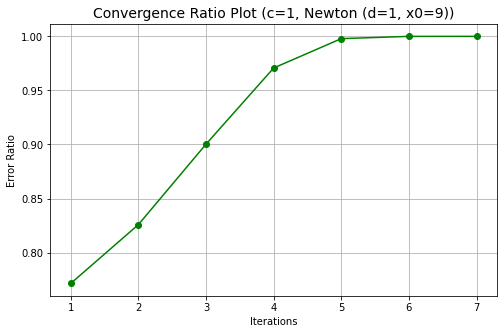

Experiment completed for d=1, x0=9, c=1.
Results saved as newton_results_d1_x09.png and newton_experiment_info_d1_x09.png.
Error + Residual plot saved as newton_error_residual_d1_x09.png.


In [113]:
# Experiment parameters
d = 1  # Multiplicity of the root
p = 1
q = 5
x_0 = 9  # Initial guess
r = 0  # Real root
TOL_error = 1e-8  # Error tolerance
TOL_residual = 1e-8  # Residual tolerance
MAX_ITER = 1000  # Maximum iterations
c = 1  # Convergence constant for the ratio plot

# Run a single experiment
run_newton_experiment(p=p, q=q, x_0=x_0, r=r, TOL_error=TOL_error, TOL_residual=TOL_residual, MAX_ITER=MAX_ITER, c=c)



Modified Newton's Experiment

Table saved as c:\Users\DELL\Desktop\FCM Directory\Program 4\modified_newton_results_d2_x09_m3.png
Experiment information saved as c:\Users\DELL\Desktop\FCM Directory\Program 4\modified_newton_experiment_info_d2_x09_m3.png
Convergence plots saved as c:\Users\DELL\Desktop\FCM Directory\Program 4\modified_newton_error_residual_d2_x09_m3.png
Displaying the convergence ratio plot...


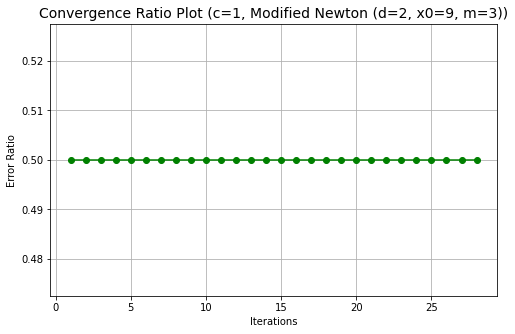

Experiment completed for d=2, x0=9, m=3, c=1.
Results saved as modified_newton_results_d2_x09_m3.png and modified_newton_experiment_info_d2_x09_m3.png.
Error + Residual plot saved as modified_newton_error_residual_d2_x09_m3.png.


In [111]:
# Experiment parameters
d = 2  # Multiplicity of the root
x_0 = 2 + 7  # Initial guess
r = 2  # Real root
TOL_error = 1e-8  # Error tolerance
TOL_residual = 1e-8  # Residual tolerance
MAX_ITER = 1000  # Maximum iterations
c = 1  # Convergence constant for the ratio plot
m = 3  # Multiplicity parameter (m=1 corresponds to standard Newton's method)

# Run a single experiment
run_modified_newton_experiment(d=d, x_0=x_0, r=r, TOL_error=TOL_error, TOL_residual=TOL_residual, MAX_ITER=MAX_ITER, c=c, m=m)


Steffenson's Method Experiment

Algorithm found a pathological condition where the difference approximation is zero. Cannot proceed.
Table saved as c:\Users\DELL\Desktop\FCM Directory\Program 4\steffensen_results_x017.png
Experiment information saved as c:\Users\DELL\Desktop\FCM Directory\Program 4\steffensen_experiment_info_x017.png
Convergence plots saved as c:\Users\DELL\Desktop\FCM Directory\Program 4\steffensen_error_residual_x017.png
Displaying the convergence ratio plot...


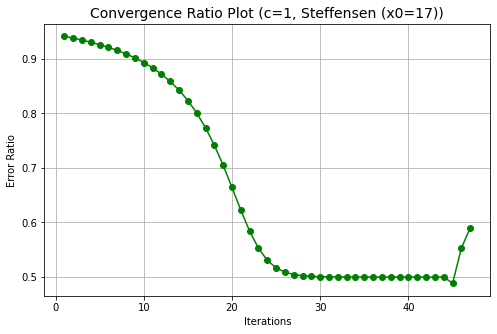

Experiment completed for x0=17, c=1.
Results saved as steffensen_results_x017.png and steffensen_experiment_info_x017.png.
Error + Residual plot saved as steffensen_error_residual_x017.png.


In [109]:
# Experiment parameters
d = 2  # Multiplicity of the root
x_0 = 2 + 15  # Initial guess
r = 2  # Real root
TOL_error = 1e-8  # Error tolerance
TOL_residual = 1e-8  # Residual tolerance
MAX_ITER = 1000  # Maximum iterations
c =  1# Convergence constant for the ratio plot

# Run a single experiment
run_steffensen_experiment(d=d, x_0=x_0, r=r, TOL_error=TOL_error, TOL_residual=TOL_residual, MAX_ITER=MAX_ITER, c=c)


Secant Method Experiment

Table saved as c:\Users\DELL\Desktop\FCM Directory\Program 4\secant_results_x06_x17.png
Experiment information saved as c:\Users\DELL\Desktop\FCM Directory\Program 4\secant_experiment_info_x06_x17.png
Convergence plots saved as c:\Users\DELL\Desktop\FCM Directory\Program 4\secant_error_residual_x06_x17.png
Displaying the convergence ratio plot...


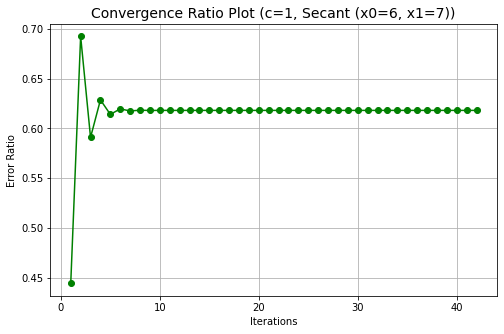

Experiment completed for x0=6, x1=7, c=1.
Results saved as secant_results_x06_x17.png and secant_experiment_info_x06_x17.png.
Error + Residual plot saved as secant_error_residual_x06_x17.png.


In [108]:
# Experiment parameters
d = 2  # Multiplicity of the root
x_0 = 2 + 4   # First initial guess
x_1 = 2 + 5  # Second initial guess
r = 2  # Real root
TOL_error = 1e-8  # Error tolerance
TOL_residual = 1e-8  # Residual tolerance
MAX_ITER = 1000  # Maximum iterations
c = 1  # Convergence constant for the ratio plot

# Run a single experiment
run_secant_experiment(d, x_0=x_0, x_1=x_1, r=r, TOL_error=TOL_error, TOL_residual=TOL_residual, MAX_ITER=MAX_ITER, c=c)


Regula Falsi Experiment

Table saved as c:\Users\DELL\Desktop\FCM Directory\Program 4\regula_falsi_results_a-10_b10.png
Experiment information saved as c:\Users\DELL\Desktop\FCM Directory\Program 4\regula_falsi_experiment_info_a-10_b10.png
Convergence plots saved as c:\Users\DELL\Desktop\FCM Directory\Program 4\regula_falsi_error_residual_a-10_b10.png
Displaying the convergence ratio plot...


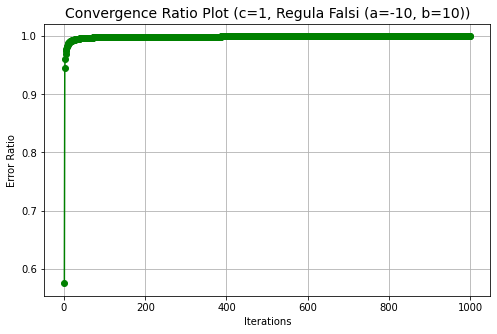

Experiment completed for a=-10, b=10, c=1.
Results saved as regula_falsi_results_a-10_b10.png and regula_falsi_experiment_info_a-10_b10.png.
Error + Residual plot saved as regula_falsi_error_residual_a-10_b10.png.


In [60]:
# Experiment parameters
d = 7  # Multiplicity of the root
a = -10  # Lower bound of the interval
b = 10 # Upper bound of the interval
r = 2  # Real root
TOL_error = 1e-8  # Error tolerance
TOL_residual = 1e-8  # Residual tolerance
MAX_ITER = 1000  # Maximum iterations
c = 1  # Convergence constant for the ratio plot

# Run a single experiment
run_regula_falsi_experiment(d, a=a, b=b, r=r, TOL_error=TOL_error, TOL_residual=TOL_residual, MAX_ITER=MAX_ITER, c=c)
